<a href="https://colab.research.google.com/github/kondreddygarivani-bit/projext-6-C-vs-D/blob/main/W_6cat_vs_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Runtime → Change runtime type → GPU → Save
import torch
print("GPU:", torch.cuda.is_available())

GPU: True


In [10]:
!pip install nbstripout
!nbstripout --install

fatal: --local can only be used inside a git repository
Installation failed: not a git repository!


In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

(train_ds, val_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)
print("Loaded!")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.ILPQT3_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Loaded!


In [3]:
IMG_SIZE = 160
BATCH_SIZE = 32

# Augmentation for training — creates variety
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

def preprocess_train(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 127.5 - 1  # normalize to [-1, 1]
    image = augmentation(image, training=True)
    return image, label

def preprocess_val(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 127.5 - 1  # same normalization
    return image, label

train_ds = train_ds.map(preprocess_train).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess_val).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Preprocessing done!")

Preprocessing done!


In [4]:
# Load MobileNetV2 — pretrained on ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base first
base_model.trainable = False

# Build model
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model ready!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
print("Phase 1 — Training top layers only...\n")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

print(f"\nPhase 1 done! Val accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Phase 1 — Training top layers only...

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 348s 583ms/step - accuracy: 0.8100 - loss: 0.4085 - val_accuracy: 0.9583 - val_loss: 0.1531
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 338s 573ms/step - accuracy: 0.9139 - loss: 0.2151 - val_accuracy: 0.9712 - val_loss: 0.1000
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 326s 552ms/step - accuracy: 0.9278 - loss: 0.1789 - val_accuracy: 0.9740 - val_loss: 0.0824
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 300s 507ms/step - accuracy: 0.9331 - loss: 0.1653 - val_accuracy: 0.9770 - val_loss: 0.0736
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 302s 512ms/step - accuracy: 0.9360 - loss: 0.1564 - val_accuracy: 0.9776 - val_loss: 0.0681

Phase 1 done! Val accuracy: 97.76%


In [ ]:
# Unfreeze top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),  # 10x lower
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 — Fine-tuning top layers...\n")

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

print(f"\nFinal val accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Phase 2 — Fine-tuning top layers...

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 185s 276ms/step - accuracy: 0.9107 - loss: 0.2077 - val_accuracy: 0.9789 - val_loss: 0.0574
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 152s 248ms/step - accuracy: 0.9336 - loss: 0.1580 - val_accuracy: 0.9834 - val_loss: 0.0513
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 153s 250ms/step - accuracy: 0.9430 - loss: 0.1413 - val_accuracy: 0.9817 - val_loss: 0.0505
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 152s 250ms/step - accuracy: 0.9486 - loss: 0.1254 - val_accuracy: 0.9822 - val_loss: 0.0492
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 151s 248ms/step - accuracy: 0.9505 - loss: 0.1253 - val_accuracy: 0.9828 - val_loss: 0.0484

Final val accuracy: 98.34%


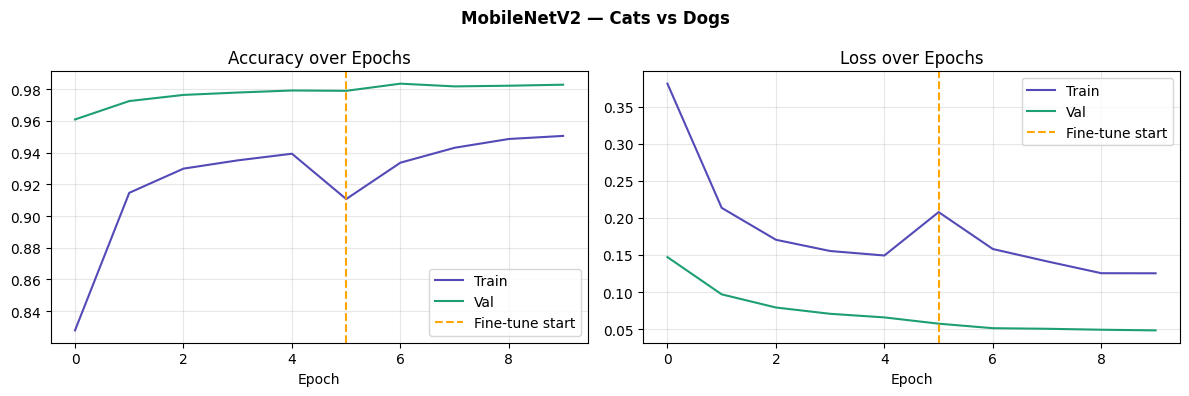

In [ ]:
# Combine both histories
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acc,     label='Train', color='#534AB7')
axes[0].plot(val_acc, label='Val',   color='#1D9E75')
axes[0].axvline(x=5, color='orange', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss,     label='Train', color='#534AB7')
axes[1].plot(val_loss, label='Val',   color='#1D9E75')
axes[1].axvline(x=5, color='orange', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 — Cats vs Dogs', fontweight='bold')
plt.tight_layout()
plt.savefig('mobilenet_curves.png', dpi=150)
plt.show()

Saving image2.jpg to image2.jpg
Saving images1.jpg to images1.jpg


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


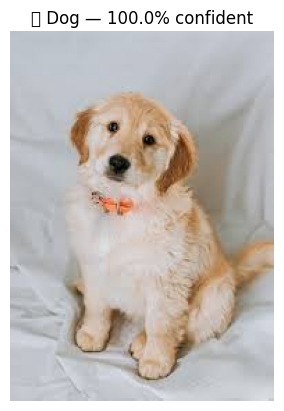

Result: 🐶 Dog
Confidence: 100.0%


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import io

# Upload your image
uploaded = files.upload()

# Predict on it
filename = list(uploaded.keys())[0]
img = Image.open(filename).convert('RGB').resize((160, 160))
img_array = np.array(img, dtype=np.float32) / 127.5 - 1
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array, verbose=0)[0][0]
result = "🐶 Dog" if pred > 0.5 else "🐱 Cat"
confidence = pred if pred > 0.5 else 1 - pred

plt.imshow(Image.open(filename))
plt.title(f"{result} — {confidence*100:.1f}% confident")
plt.axis('off')
plt.show()

print(f"Result: {result}")
print(f"Confidence: {confidence*100:.1f}%")

In [6]:
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>